### 1. Import Dependecies

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

### 2. Import data

In [2]:
df = pd.read_csv("data/processed/estate_Binning_Applied.csv")
df.head()

,IncomeLevel,TotalRooms,TotalBedrooms,NeighborhoodPop,AvgOccupancy,Latitude,Longitude,TargetPrice,RoomsPerHousehold,BedroomsRatio,PropertyAge_bins
0,3.287977,5.128150,0.990769,2339.474039,3.739113,32.71,-117.03,1.030,1.359130,0.200576,Moderate
1,3.804601,4.372696,1.040469,1269.383596,1.429576,33.77,-118.16,3.821,2.573820,0.232703,Old
2,2.029509,4.131418,1.032285,1455.381923,3.914447,32.69,-117.11,0.934,1.002116,0.258269,Old
3,3.540823,6.270531,1.147146,895.050628,2.681969,36.78,-119.80,0.965,2.725400,0.180940,Old
4,6.609324,6.178103,0.986182,2698.088189,3.457448,37.42,-121.86,2.648,1.867161,0.160572,Moderate


In [3]:
categorical_columns = ['PropertyAge_bins']

### 3.  Univariate Analysis

In [4]:
for col in categorical_columns:
    print(f"\n=== {col} ===")

    temp = pd.DataFrame({
        'Count': df[col].value_counts(),
        'Percent': df[col].value_counts(normalize=True) * 100
    })

    temp = temp.round(2)   # optional: round percentages
    print(temp)


=== PropertyAge_bins ===
                  Count  Percent
PropertyAge_bins                
Moderate           7954    52.33
Old                4982    32.78
New                2263    14.89


In [5]:
for col in categorical_columns:
    print(f"\nMean TargetPrice by {col}:")
    print(df.groupby(col)['TargetPrice'].mean())


Mean TargetPrice by PropertyAge_bins:
PropertyAge_bins
Moderate    2.023912
New         1.946147
Old         2.193196
Name: TargetPrice, dtype: float64


### 4. Bivariate Analysis

In [6]:
# For estate dataset, PropertyAge_bins has 3 categories and target is continuous (TargetPrice).
# We run an ANOVA (f_oneway) test to see if the mean TargetPrice differs significantly across categories.
groups = [df[df['PropertyAge_bins'] == val]['TargetPrice'] for val in df['PropertyAge_bins'].unique()]
f_stat, p = f_oneway(*groups)
print(f"PropertyAge_bins: p-value = {p:.4f}")

PropertyAge_bins: p-value = 0.0000


In [7]:
numerical_columns = ['IncomeLevel', 'TotalRooms', 'TotalBedrooms', 'NeighborhoodPop', 'AvgOccupancy', 'Latitude', 'Longitude', 'TargetPrice', 'RoomsPerHousehold', 'BedroomsRatio']

In [8]:
# We perform a T-test between 'New' and 'Old' properties' TargetPrice
new_properties = df[df['PropertyAge_bins'] == 'New']['TargetPrice']
old_properties = df[df['PropertyAge_bins'] == 'Old']['TargetPrice']
t, p = ttest_ind(new_properties, old_properties, nan_policy='omit')
print(f"TargetPrice (New vs Old): p-value = {p:.4f}")

TargetPrice (New vs Old): p-value = 0.0000


### 5. Correlation Matrix

In [9]:
numerical_columns = ['IncomeLevel', 'TotalRooms', 'TotalBedrooms', 'NeighborhoodPop', 'AvgOccupancy', 'Latitude', 'Longitude', 'TargetPrice', 'RoomsPerHousehold', 'BedroomsRatio']

In [10]:
corr_matrix = df[numerical_columns].corr()

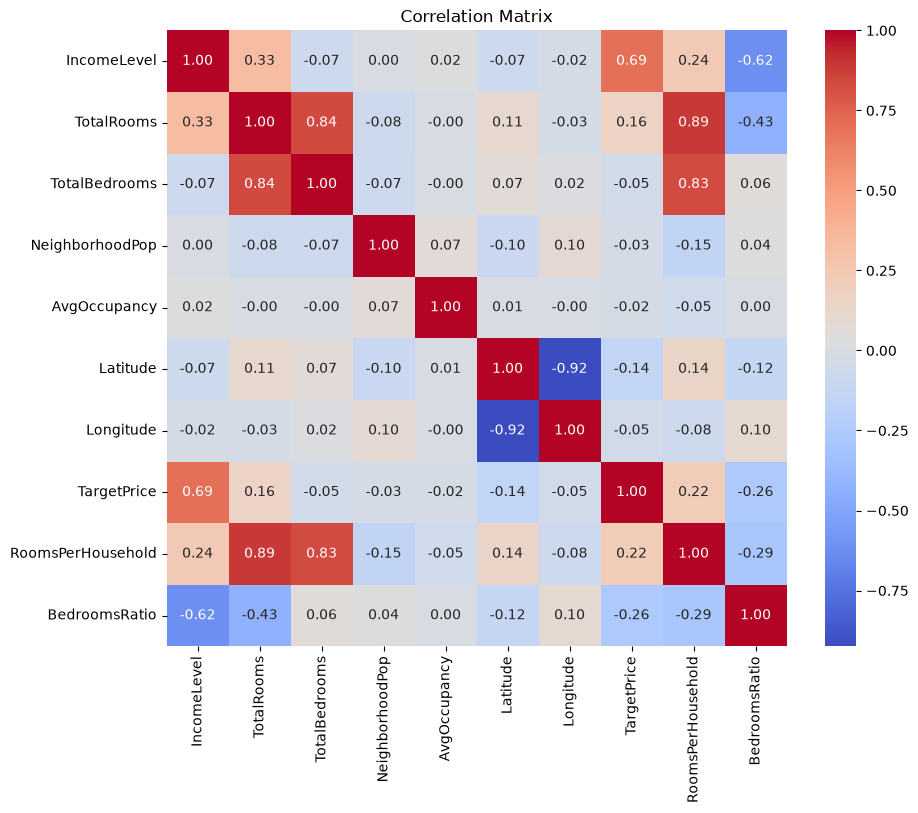

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()